<a href="https://colab.research.google.com/github/PriscillaAlmeida07/ifood-data-science/blob/main/notebooks/ifood_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Delivery Times Analysis

In [162]:
# Dependencies
# This project uses the following libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Skit Learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score)
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor


### Loading the dataset and checking some key information to get a clear overview for our analysis.

In [163]:
# Loading the file
df_original = pd.read_csv('Food_Delivery_Times.csv', sep=',')

# Create a copy to compare differences later
df_copy = df_original.copy()

In [164]:
# Exploratory analysis

# Display a concise summary of the DataFrame, including data types and non-null values.
print('------------------ Overview ------------------\n')
df_copy.info()

# Calculate and display the count of missing values for each column.
print('\n------------------ Missing values ------------------\n')
print(df_copy.isna().sum())

# Display the first 20 rows of the DataFrame to get a preliminary look at the data.
print('\n------------------ 10 rows ------------------\n')
df_copy.head(10)

------------------ Overview ------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB

------------------ Missing values ------------------

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
V

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


###  Splitting numerical and categorical features




In [165]:
numerical_features = df_copy.columns[(df_copy.dtypes == 'int64') | (df_copy.dtypes == 'float64')]
print(f'Numerical features: {numerical_features}')
categorical_features = df_copy.columns[df_copy.dtypes == 'object']
print(f'Categorical features: {categorical_features}')


Numerical features: Index(['Order_ID', 'Distance_km', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Delivery_Time_min'],
      dtype='object')
Categorical features: Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='object')


### Analyzing categorical features (columns)




In [166]:
# Analyzing data patterns by grouping each categorical feature
for i in categorical_features:
    print(f'\n------------------ {i} ------------------\n')
    print(df_copy.groupby([i]).size())


------------------ Weather ------------------

Weather
Clear    470
Foggy    103
Rainy    204
Snowy     97
Windy     96
dtype: int64

------------------ Traffic_Level ------------------

Traffic_Level
High      197
Low       383
Medium    390
dtype: int64

------------------ Time_of_Day ------------------

Time_of_Day
Afternoon    284
Evening      293
Morning      308
Night         85
dtype: int64

------------------ Vehicle_Type ------------------

Vehicle_Type
Bike       503
Car        195
Scooter    302
dtype: int64


### Data Visualization with Matplotlib and Seaborn


/tmp/ipykernel_5041/2123984735.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i][0].set_xticklabels(ax[i][0].get_xticklabels(), rotation=45) # Rotate the names if they are too long
/tmp/ipykernel_5041/2123984735.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i][0].set_xticklabels(ax[i][0].get_xticklabels(), rotation=45) # Rotate the names if they are too long
/tmp/ipykernel_5041/2123984735.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i][0].set_xticklabels(ax[i][0].get_xticklabels(), rotation=45) # Rotate the names if they are too long
/tmp/ipykernel_5041/2123984735.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i][0].s

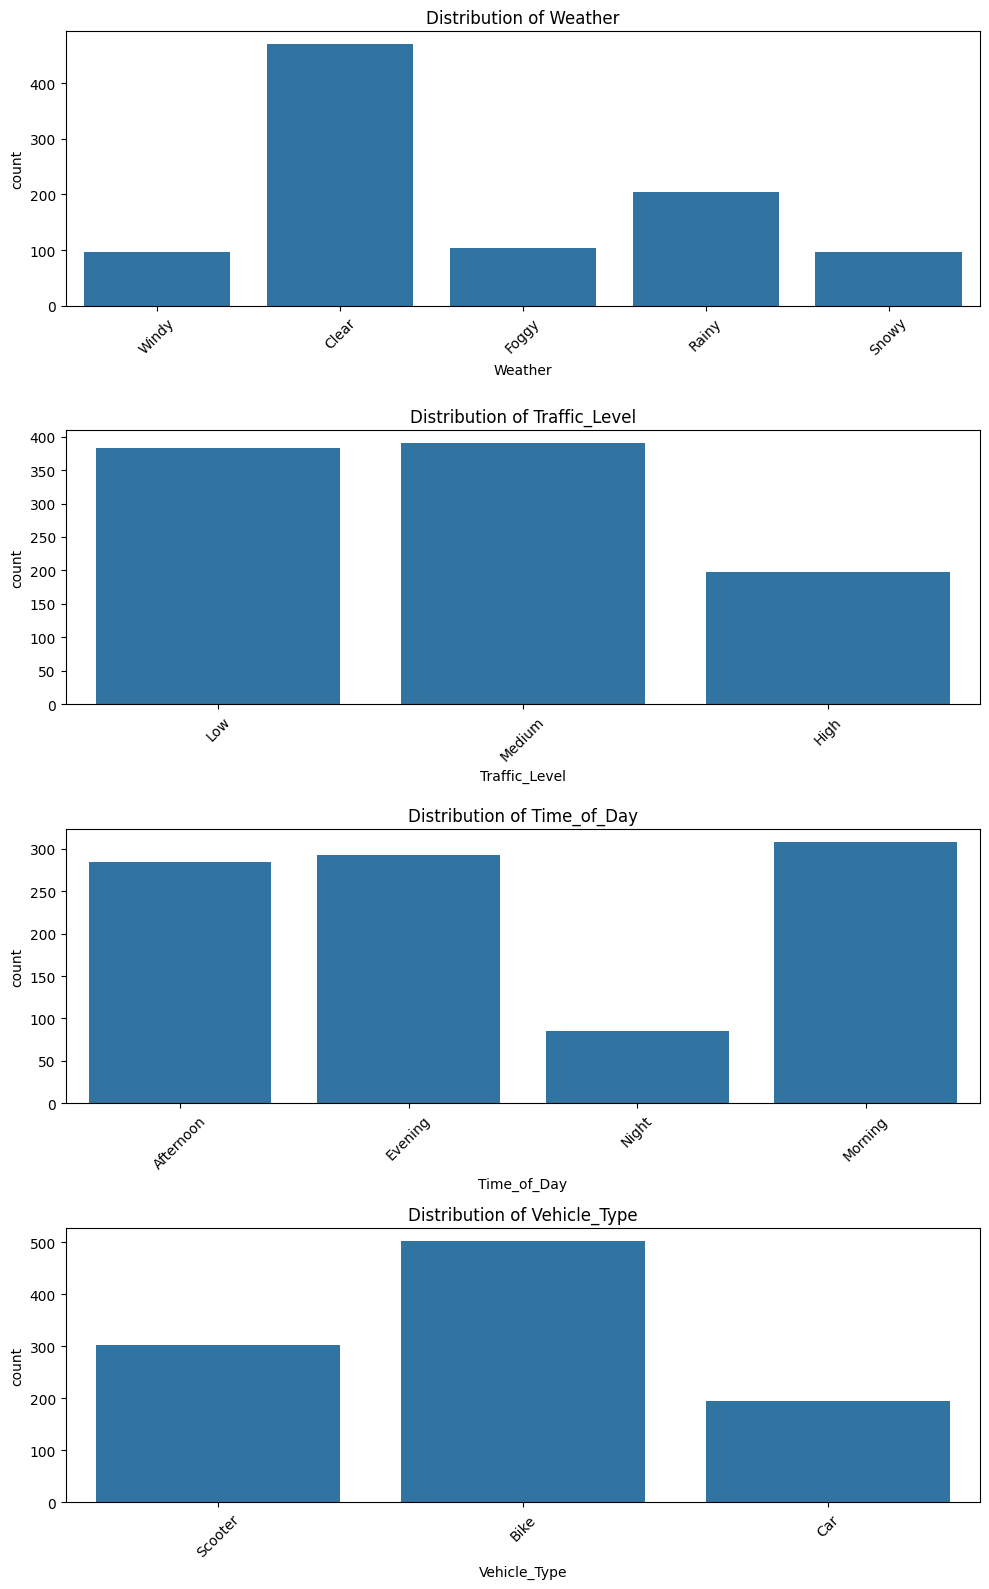

In [167]:
# categorical features
# Visualizing data with bar plots

n = len(categorical_features)

fig, ax = plt.subplots(n, 1, figsize=(10, 4 * n), squeeze=False)

for i, column in enumerate(categorical_features):
    # sns.countplot automatically counts the values and creates the bars.
    sns.countplot(data=df_copy, x=column, ax=ax[i][0])
    ax[i][0].set_title(f'Distribution of {column}')
    ax[i][0].set_xticklabels(ax[i][0].get_xticklabels(), rotation=45) # Rotate the names if they are too long

plt.tight_layout()
plt.show()

### Visualizing outliers

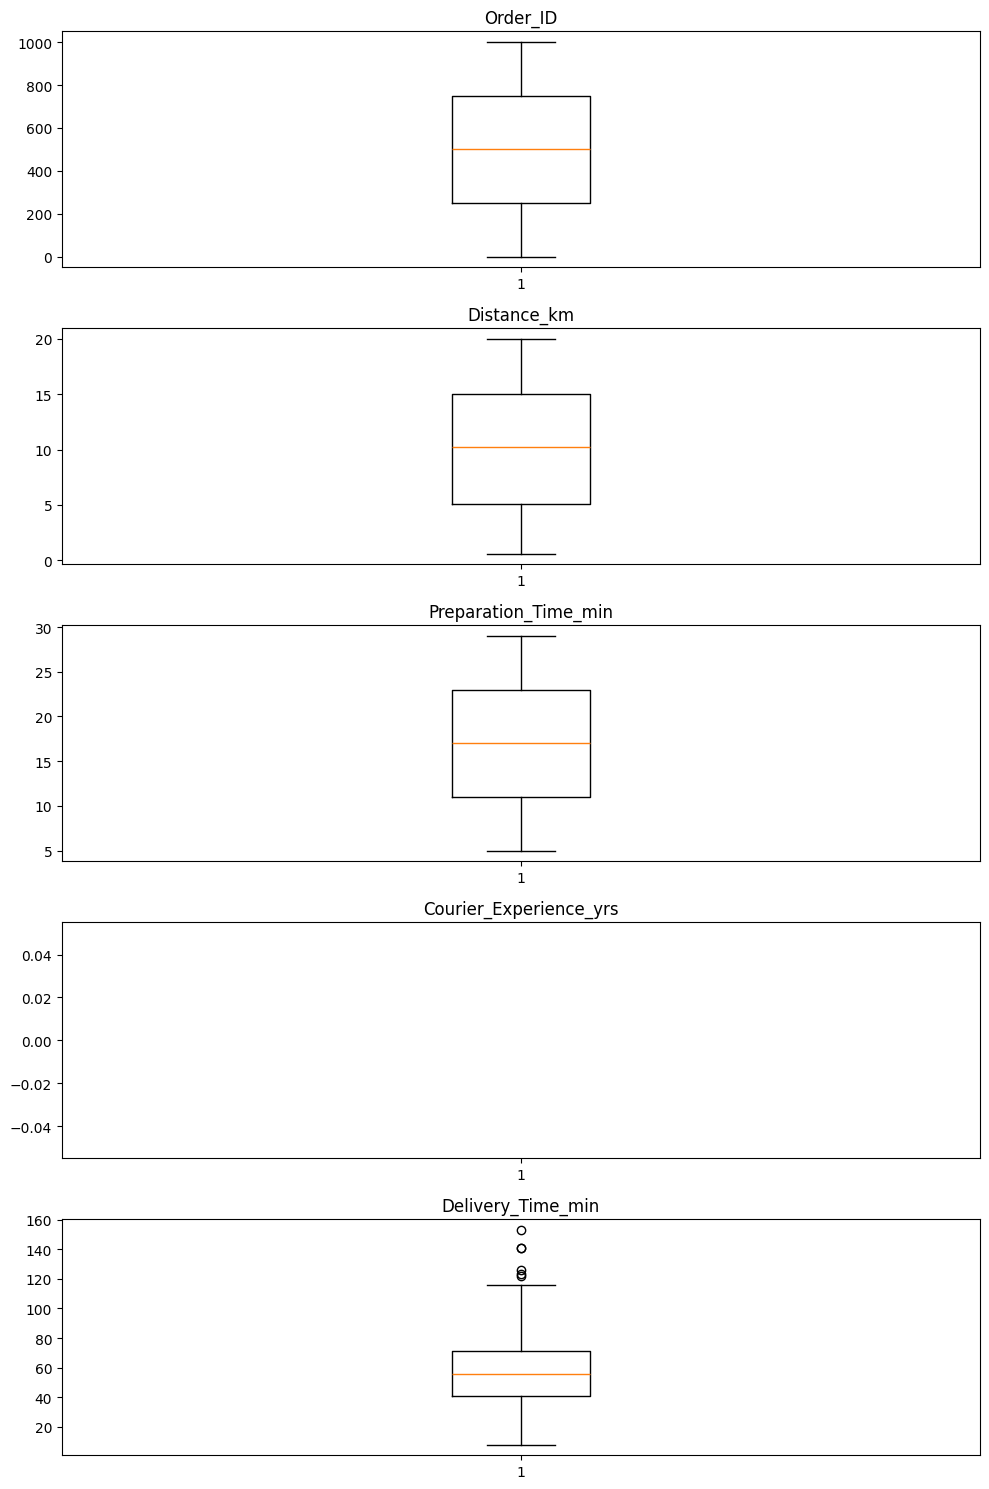

In [168]:
n = len(numerical_features)

fig, ax = plt.subplots(n, figsize=(10, 3*n))

for i, column in enumerate(numerical_features):
    ax[i].boxplot(df_copy[column])
    ax[i].set_title(column)

plt.tight_layout()
plt.show()


 ### Handling outliers

(994, 9)


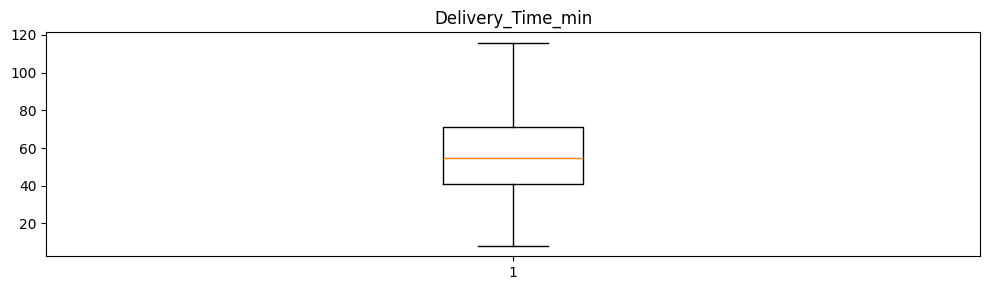

In [169]:
## Handling Delivery Time outliers
df1 = df_copy.loc[df_copy['Delivery_Time_min'] <= 120]
print(df1.shape)

fig, ax = plt.subplots(figsize=(10, 3))

ax.boxplot(df1['Delivery_Time_min'])
ax.set_title('Delivery_Time_min')

plt.tight_layout()
plt.show()


### Checking duplicate rows

In [170]:
# Check for duplicate rows in the DataFrame.
df1.duplicated().sum()
# Conclusion: The output of 0 confirms that there are no duplicate entries in the dataset.

np.int64(0)

### Verifying impossible values

In [171]:
# Let's verify if a value is impossible
for col in numerical_features:
    print(f'\n------------------ {col} ------------------\n')
    print(df1[col].min())
# Since neither value is negative, everything is ok


------------------ Order_ID ------------------

1

------------------ Distance_km ------------------

0.59

------------------ Preparation_Time_min ------------------

5

------------------ Courier_Experience_yrs ------------------

0.0

------------------ Delivery_Time_min ------------------

8


Correlation

In [172]:
# Compute correlations for all numerical columns with 'Delivery_Time_min' and sort them in descending order.
df1.corr(numeric_only=True)['Delivery_Time_min'].sort_values(ascending=False)

# Conclusion: 'Distance_km' exhibits the strongest positive correlation with 'Delivery_Time_min'.
# This implies that as the delivery distance increases, the delivery time tends to increase proportionally.

,Delivery_Time_min
Delivery_Time_min,1.000000
Distance_km,0.788343
Preparation_Time_min,0.307307
Order_ID,-0.043732
Courier_Experience_yrs,-0.088281


### Analyze the influence of categorical variables on 'Delivery_Time_min

In [173]:
# Analyze the influence of categorical variables on 'Delivery_Time_min' by calculating the mean delivery time for each category.
for col in categorical_features:
    result = df1.groupby(col)['Delivery_Time_min'].agg(
        ['mean', 'count']
    ).sort_values('mean', ascending=False)

    print(f'\n---------- {col} ----------')
    print(result)



---------- Weather ----------
              mean  count
Weather                  
Snowy    67.113402     97
Foggy    59.466019    103
Rainy    59.064356    202
Windy    54.757895     95
Clear    52.531049    467

---------- Traffic_Level ----------
                    mean  count
Traffic_Level                  
High           64.515306    196
Medium         55.848329    389
Low            52.228947    380

---------- Time_of_Day ----------
                  mean  count
Time_of_Day                  
Evening      56.744828    290
Afternoon    56.080986    284
Morning      55.892508    307
Night        55.211765     85

---------- Vehicle_Type ----------
                   mean  count
Vehicle_Type                  
Car           57.419689    193
Bike          56.275449    501
Scooter       55.500000    300


### Training the model to can prever the delivery time temo de entrega

In [174]:
# Create a copy of the cleaned dataset
df2 = df1.copy()

# Define the target variable
target_feature = 'Delivery_Time_min'

# Separate predictor variables from the target variable
predictors = df2.drop(columns=[target_feature])
target = df2[target_feature]

print('Features:')
print(predictors.columns.tolist())

print('\nTarget:')
print(target_feature)

# pipelines
numerical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
              'encoder',
              OneHotEncoder(
                  handle_unknown='ignore',
                  sparse_output=False
              )
          )
    ]
)

# Create a list of numerical features that are not the target feature
numerical_features_for_preprocessing = [col for col in numerical_features if col != target_feature]

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'numerical',
            numerical_pipeline,
            numerical_features_for_preprocessing
        ),
        (
            'categorical',
            categorical_pipeline,
            categorical_features
        )
    ]
)

Features:
['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs']

Target:
Delivery_Time_min


In [175]:
# Function to evalute the models
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test) # Make predictions on the test set

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'========== {model_name} ==========')
    print(f'MAE:  {mae:.2f} minutes')
    print(f'RMSE: {rmse:.2f} minutes')
    print(f'R²:   {r2:.3f}')

    return mae, rmse, r2

In [176]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    predictors,
    target,
    test_size=0.20,
    random_state=300
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

# 1- (Linear Regression). Create a pipeline with preprocessing and the regression model
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

# Evalute Linear Regression
linear_result = evaluate_model(
    linear_model,
    X_test,
    y_test,
    'Linear Regression'
)

# 1- (random Forest Regression). Create a Random Forest regression pipeline
random_forest = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            random_state=300,
            n_jobs=-1
        ))
    ]
)

# Train the model
random_forest.fit(X_train, y_train)

# Evalute
random_forest_result = evaluate_model(
    random_forest,
    X_test,
    y_test,
    'Random Forest'
)

Training set: (795, 8)
Test set: (199, 8)
========== Linear Regression ==========
MAE:  7.09 minutes
RMSE: 10.75 minutes
R²:   0.748
========== Random Forest ==========
MAE:  7.55 minutes
RMSE: 11.65 minutes
R²:   0.704


### Let's compare the two models:

In [177]:
results = pd.DataFrame(
    [
        linear_result,
        random_forest_result
    ],
    columns=['MAE', 'RMSE', 'R²'] # Add column names
)
results.sort_values(
    by='MAE', # Sort by the 'MAE' column name
    ascending=True,
    inplace=True # Apply sort in place
)

results

,MAE,RMSE,R²
0,7.087273,10.751675,0.747703
1,7.548116,11.647036,0.703933


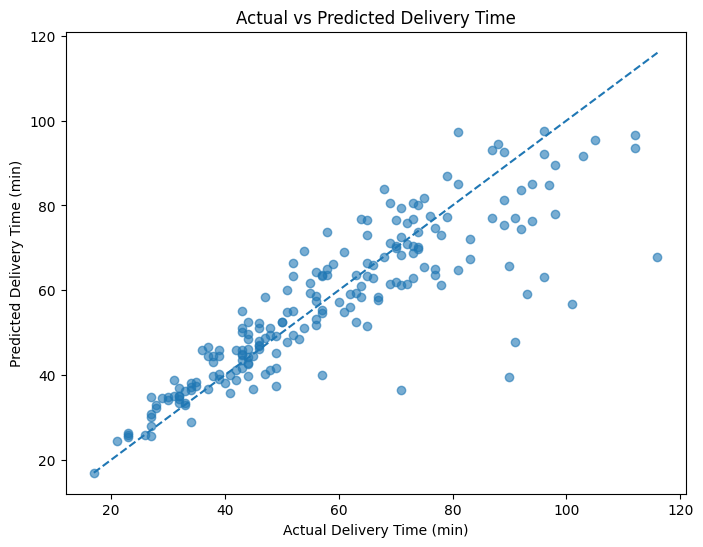

In [178]:
# Graphically
model = linear_model
y_pred = model.predict(X_test)
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Add the ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title('Actual vs Predicted Delivery Time')

plt.show()

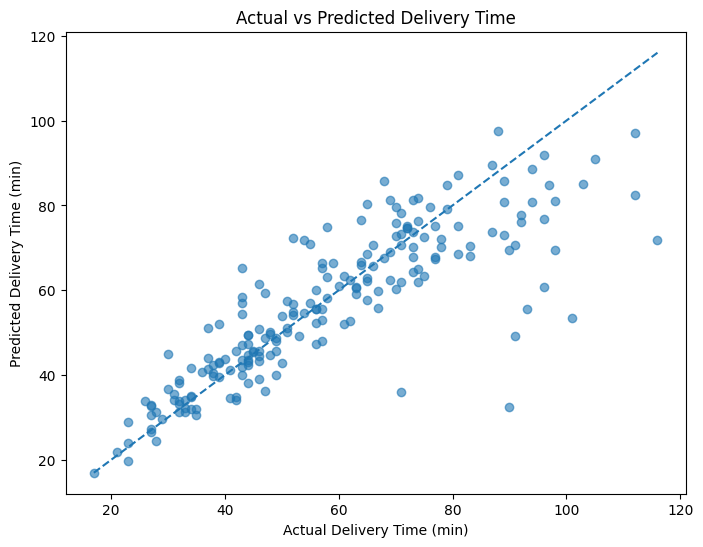

In [179]:
# Generate predictions using the selected model
model = random_forest
y_pred = model.predict(X_test)
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Add the ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title('Actual vs Predicted Delivery Time')

plt.show()